In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
from joblib import Parallel, delayed
from tqdm import tqdm
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

from NSC_cosmo_old import PertEMD_noAX as PertEMD_noAX2
from NSC_cosmo_old import background as background2
import shutil, os


texlive_path = "/usr/local/texlive/2026/bin/x86_64-linux"
os.environ["PATH"] = texlive_path + ":" + os.environ["PATH"]

plt.rcParams.update({
    "pdf.fonttype": 42,  
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 16,
    
    "axes.labelsize": 20,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})


labR = r'$R/R_I$'
labx  = r'$x$'
labka = r'$\kappa$'
labrh= r'$\rho_i$~[GeV$^4$]'
labT = r'$T$~[GeV]'
labdr= r'$|\delta_r(\kappa,x)|$'
labdp= r'$|\delta_\phi(\kappa,x)|$'
labtr= r'$|\theta_r(\kappa,x)|/k_{\mathrm{RH}}$'
labtp= r'$|\theta_\phi(\kappa,x)|/k_{\mathrm{RH}}$'
labPh= r'$|\Phi(\kappa,x)|$'

labdr2= labdr
labdp2= labdp
labtr2= labtr
labtp2= labtp
labPh2= labPh

labma= r'$m_a$~[GeV]'
labth= r'$\theta_0$'
Phi_p = np.sqrt(2.101*10**(-9))



def background(Tend, Tini, maxi, EP):
    Mp = 2.4e18

    data_gstar = np.loadtxt("Data/geffdhs.dat")
    gstar = interp1d(data_gstar[:, 0], data_gstar[:, 1], bounds_error=False, fill_value="extrapolate")

    data_gstars = np.loadtxt("Data/heffdhs.dat")
    gstars = interp1d(data_gstars[:, 0], data_gstars[:, 1], bounds_error=False, fill_value="extrapolate")

    data_dgstar = np.loadtxt("Datafderivdhs.dat")
    dgstar = interp1d(data_dgstar[:, 0], data_dgstar[:, 1], bounds_error=False, fill_value="extrapolate")

    data_dgstars = np.loadtxt("Dataheffderivdhs.dat")
    dgstars = interp1d(data_dgstars[:, 0], data_dgstars[:, 1], bounds_error=False, fill_value="extrapolate")

    H_RH = float((Tend**2) * np.pi * np.sqrt(gstar(Tend) / 10.0) / (3.0 * Mp))
    Rini = 1.0
    Rmax = 1e16
    ws = 0.0
    bb = 5/2
    GG = bb * H_RH
    T_floor = 1e-30
    denom_floor = 1e-300

    def rhoSM(T):
        T = np.maximum(T, T_floor)
        return (np.pi**2 / 30.0) * gstar(T) * T**4

    def ss(T):
        T = np.maximum(T, T_floor)
        return (2.0 * np.pi**2 / 45.0) * gstars(T) * T**3

    def pressureSM(T):
        T = np.maximum(T, T_floor)
        return (np.pi**2 / 90.0) * (4.0 * gstars(T) - 3.0 * gstar(T)) * T**4

    def drhoSMdT(T):
        T = np.maximum(T, T_floor)
        return (np.pi**2 / 30.0) * T**3 * (4.0 * gstar(T) + T * dgstar(T))

    def dpressureSMdT(T):
        T = np.maximum(T, T_floor)
        return (np.pi**2 / 90.0) * T**3 * (16.0 * gstars(T) - 12.0 * gstar(T) + T * (4.0 * dgstars(T) - 3.0 * dgstar(T)))

    def rhs(R, Y):
        T, rho_phi = Y
        T = max(T, T_floor)
        rho_phi = max(rho_phi, 0.0)

        rho_r = float(rhoSM(T))
        P_r = float(pressureSM(T))
        drho_dT = max(float(drhoSMdT(T)), denom_floor)
        HH = np.sqrt((rho_r + rho_phi) / (3.0 * Mp**2))

        dTdR = (GG * rho_phi - 3.0 * HH * (rho_r + P_r)) / (R * HH * drho_dT)
        dRhoPhidR = -3.0 * (1.0 + ws) * rho_phi / R - GG * rho_phi / (HH * R)

        return [dTdR, dRhoPhidR]

    Y0 = [float(Tini), float(rhoSM(Tini) * EP)]
    R_eval = np.logspace(np.log10(Rini), np.log10(Rmax), 100000)

    sol = solve_ivp(rhs, [Rini, Rmax], Y0, method="LSODA", atol=1e-13, rtol=1e-13, t_eval=R_eval)

    R = sol.t
    Temp = np.maximum(sol.y[0], T_floor)
    Rho_phi = np.maximum(sol.y[1], 0.0)

    Rho_r = rhoSM(Temp)
    P_r = pressureSM(Temp)
    Hub = np.sqrt((Rho_phi + Rho_r) / (3.0 * Mp**2))

    dRho_r_dT = np.maximum(drhoSMdT(Temp), denom_floor)
    dP_r_dT = dpressureSMdT(Temp)

    dT_dR = (GG * Rho_phi - 3.0 * Hub * (Rho_r + P_r)) / (R * Hub * dRho_r_dT)
    dRho_r_dR = dRho_r_dT * dT_dR
    dP_r_dR = dP_r_dT * dT_dR

    idx_RH = np.argmin(np.abs(Temp - Tend))
    R_RH = float(R[idx_RH])
    k_RH = float(Hub[idx_RH] * R_RH)

    limit_R = maxi * R_RH
    mask_cut = R <= limit_R

    R_cut = R[mask_cut]
    Temp_cut = Temp[mask_cut]
    Hub_cut = Hub[mask_cut]
    Rho_phi_cut = Rho_phi[mask_cut]
    Rho_r_cut = Rho_r[mask_cut]
    P_r_cut = P_r[mask_cut]
    dT_dR_cut = dT_dR[mask_cut]
    dRho_r_dR_cut = dRho_r_dR[mask_cut]
    dP_r_dR_cut = dP_r_dR[mask_cut]
    Gamma_cut = np.full(len(R_cut), GG)

    return (
        R_cut, Rho_phi_cut, Rho_r_cut, P_r_cut, Temp_cut, Hub_cut,
        Gamma_cut, dT_dR_cut, dRho_r_dR_cut, dP_r_dR_cut, R_RH, k_RH
    )

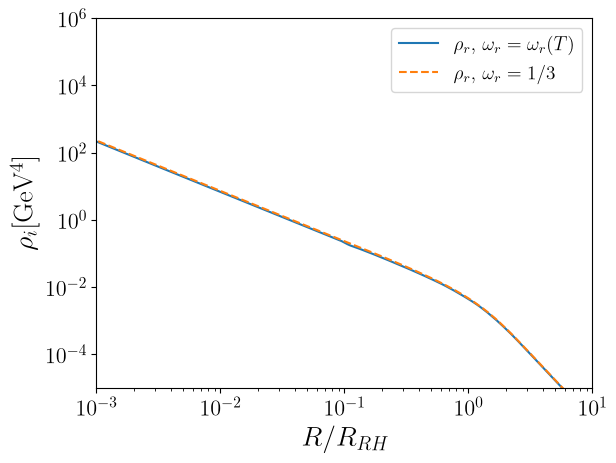

In [2]:
Tend=0.150
Tini=3e1
maxi=10
EP=1e5





R, rho_phi, rho_r, P_r, Temp, Hub, GG, dT_dR, drho_r_dR, dP_r_dR, R_RH, k_RH = background(Tend, Tini, maxi, EP)

R2, rho_phi2, rho_r2, Temp2, Hub2, GG2, R_RH2, k_RH2 = background2(Tend, Tini, maxi, EP)
R_QCD=R[np.argmin(np.abs(Temp-0.150))]
RQCD=R_QCD/R_RH
rho_rRH=rho_r[np.argmin(np.abs(R-R_RH))]
plt.loglog(R/R_RH, rho_r, label=rf'$\rho_r$, $\omega_r=\omega_r(T)$')
plt.loglog(R2/R_RH2, rho_r2,linestyle='--', label=rf'$\rho_r$, $\omega_r=1/3$')
plt.xlabel(rf'$R/R_{{RH}}$')

plt.ylabel(rf'$\rho_i$[GeV$^4$]')
plt.ylim(1e-5,1e6)
plt.xlim(1e-3,1e1)
plt.legend()

# Sound speed $c_{s,r}$

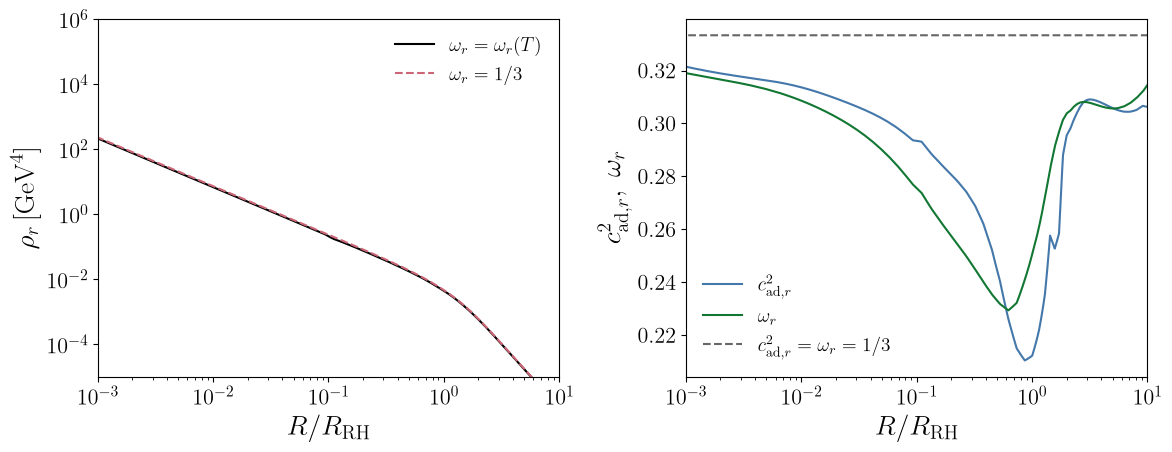

In [ ]:
data_gstar = np.loadtxt("Datas.dat")
gstar = interp1d(data_gstar[:, 0], data_gstar[:, 1], bounds_error=False, fill_value="extrapolate")

data_gstars = np.loadtxt("Dataffdhs.dat")
gstars = interp1d(data_gstars[:, 0], data_gstars[:, 1], bounds_error=False, fill_value="extrapolate")

data_dgstar = np.loadtxt("Datageffderivdhs.dat")
dgstar = interp1d(data_dgstar[:, 0], data_dgstar[:, 1], bounds_error=False, fill_value="extrapolate")

data_dgstars = np.loadtxt("Dataivdhs.dat")
dgstars = interp1d(data_dgstars[:, 0], data_dgstars[:, 1], bounds_error=False, fill_value="extrapolate")

num= (4*dgstars(Temp) - 3*dgstar(Temp)) * Temp +4*(4*gstars(Temp) - 3*gstar(Temp))
den=dgstar(Temp)*Temp + 4*gstar(Temp)

c_s1=(1/3)*num/den
c_r2=dP_r_dR/drho_r_dR
omega_r=(1/3)*((4*gstars(Temp) - 3*gstar(Temp)))/(gstar(Temp))


fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))

ax[0].loglog(R/R_RH, rho_r, color="#000000", label=r' $\omega_r=\omega_r(T)$')
ax[0].loglog(R2/R_RH2, rho_r2, color="#CC6677", linestyle='--', label=r'$\omega_r=1/3$')
ax[0].set_xlabel(r'$R/R_{\rm RH}$')
ax[0].set_ylabel(r'$\rho_r\, [{\rm GeV}^4]$')
ax[0].set_xlim(1e-3, 1e1)
ax[0].set_ylim(1e-5, 1e6)
ax[0].legend(frameon=False)

ax[1].semilogx(R/R_RH, c_s1, color="#4477AA", label=r'$c_{\mathrm{ad},r}^2$')
ax[1].semilogx(R/R_RH, omega_r, color="#117733", label=r'$\omega_r$')
ax[1].semilogx(R/R_RH, np.full_like(R, 1.0/3.0), color="#666666", linestyle='--', label=r'$c_{\mathrm{ad},r}^2=\omega_r=1/3$')
ax[1].set_xlabel(r'$R/R_{\rm RH}$')
ax[1].set_ylabel(r'$c_{\mathrm{ad},r}^2,\ \omega_r$')
ax[1].set_xlim(1e-3, 1e1)
ax[1].legend(frameon=False)

fig.tight_layout()
fig.savefig("radiation_background_nonideal.pdf", dpi=300, bbox_inches='tight')
plt.show()

# $\delta_r = \left[4+\frac{T}{g_\star}\frac{d\, g_\star}{d\,T}\right]\frac{\delta\, T}{T}\approx \,4\frac{\delta\, T}{T} $??

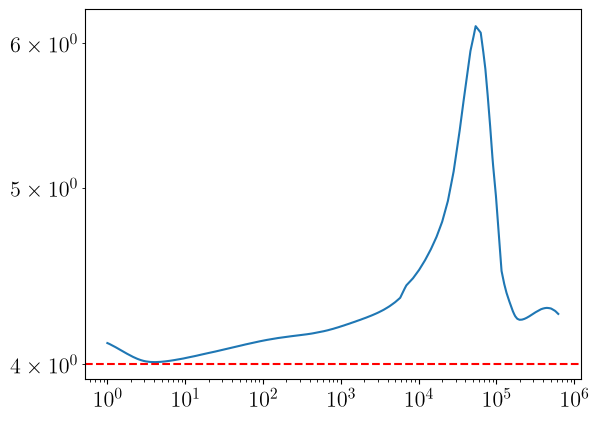

In [4]:
full_term=4+(Temp/gstar(Temp))*dgstar(Temp)
plt.loglog(R, full_term, label='full_term')
plt.axhline(y=4, color='r', linestyle='--', label='y=4')


# Perturbation time

In [5]:
import numpy as np
from scipy.integrate import solve_ivp
from numba import njit

@njit
def perturbations_njit(R_val, Y, k, R_arr, rho_phi_arr, rho_r_arr, GG_arr, c_r2_arr, omega_r_arr):
    Mp = 2.4e18
    delta_phi, theta_phi, delta_r, theta_r, Phi = Y
    rho_phi_val = np.interp(R_val, R_arr, rho_phi_arr)
    rho_r_val = np.interp(R_val, R_arr, rho_r_arr)
    gamma_phi_val = np.interp(R_val, R_arr, GG_arr)
    c_r2_val = np.interp(R_val, R_arr, c_r2_arr)
    w_r_val = np.interp(R_val, R_arr, omega_r_arr)
    eps = 1e-300
    rho_tot = rho_phi_val + rho_r_val
    E_val = np.sqrt(max(rho_tot, 0.0)/(3.0*Mp**2)) + eps
    ratio = rho_phi_val/(rho_r_val + eps)
    gamma_ratio = ratio*(gamma_phi_val/(R_val*E_val))
    rho_delta_phi = rho_phi_val*delta_phi
    inv_R2_E = 1.0/(R_val**2*E_val)
    k2_inv_R2_E = k**2*inv_R2_E
    dPhi_dR = -((rho_delta_phi + rho_r_val*delta_r)/(6.0*Mp**2*R_val*E_val**2) + (k**2/(3.0*R_val**3*E_val**2) + 1.0/R_val)*Phi)
    ddelta_phi_dR = -(gamma_phi_val/(R_val*E_val))*Phi - inv_R2_E*theta_phi + 3.0*dPhi_dR
    dtheta_phi_dR = k2_inv_R2_E*Phi - theta_phi/R_val
    den_r = 1.0 + w_r_val
    ddelta_r_dR = gamma_ratio*(delta_phi + Phi - delta_r) - (3.0/R_val)*(c_r2_val - w_r_val)*delta_r - den_r*inv_R2_E*theta_r + 3.0*den_r*dPhi_dR
    dtheta_r_dR = (gamma_ratio/den_r)*(theta_phi - (1.0 + c_r2_val)*theta_r) - ((1.0 - 3.0*c_r2_val)/R_val)*theta_r + k2_inv_R2_E*((c_r2_val/den_r)*delta_r + Phi)
    return np.array([ddelta_phi_dR, dtheta_phi_dR, ddelta_r_dR, dtheta_r_dR, dPhi_dR])

def PertEMD_noAX(rho_phi, rho_r, c_r2, omega_r, GG, R, k):
    R = np.asarray(R, dtype=np.float64)
    rho_r = np.asarray(rho_r, dtype=np.float64)
    rho_phi = np.asarray(rho_phi, dtype=np.float64)
    c_r2 = np.asarray(c_r2, dtype=np.float64)
    omega_r = np.asarray(omega_r, dtype=np.float64)
    GG = np.asarray(GG, dtype=np.float64)
    k = float(k)
    Rmax = float(R[-1])
    Rini = float(R[0])
    Phi_ini = np.sqrt(2.101e-9)
    Delta_phi_ini = -2.0*Phi_ini
    Delta_r_ini = -2.0*Phi_ini if rho_phi[0] < rho_r[0] else -Phi_ini
    Y0 = np.array([Delta_phi_ini, 0.0, Delta_r_ini, 0.0, Phi_ini], dtype=np.float64)
    sols = solve_ivp(perturbations_njit, [Rini, Rmax], Y0, method="Radau", atol=1e-13, rtol=1e-13, t_eval=R, args=(k, R, rho_phi, rho_r, GG, c_r2, omega_r))
    if not sols.success:
        raise RuntimeError(f"The integrator failed: {sols.message}")
    delta_phi_res = sols.y[0]
    theta_phi_res = sols.y[1]
    delta_r_res = sols.y[2]
    theta_r_res = sols.y[3]
    Phi_res = sols.y[4]
    dPhi_dR_res = np.zeros(len(R), dtype=np.float64)
    for i in range(len(R)):
        dPhi_dR_res[i] = perturbations_njit(R[i], sols.y[:, i], k, R, rho_phi, rho_r, GG, c_r2, omega_r)[4]
    return delta_r_res, delta_phi_res, Phi_res, theta_phi_res, theta_r_res, dPhi_dR_res


In [6]:
kappas_log = np.logspace(np.log10(0.1), np.log10(250), 450)
kappas_special = np.array([100.0, 50.0, 10.0, 1.0, 0.1])
kappas = np.unique(np.concatenate([kappas_log, kappas_special]))
k_vals = k_RH*kappas
n_workers = max(1, min(len(k_vals), int(mp.cpu_count()*0.55)))

def run_grid(worker, label):
    print(f"Calculating {len(k_vals)} modes with {label} using {n_workers} cores...")
    return list(tqdm(Parallel(n_jobs=n_workers, return_as="generator")(delayed(worker)(k) for k in k_vals), total=len(k_vals), desc=label))

def worker_old(k):
    return PertEMD_noAX2(rho_phi, rho_r, GG, R, k)

def worker_new(k):
    return PertEMD_noAX(rho_phi, rho_r, c_r2, omega_r, GG, R, k)

pert_results2 = run_grid(worker_old, "old")
delta_r_k2, delta_phi_k2, Phi_k2, theta_phi_k2, theta_r_k2, dPhi_dR_k2 = map(list, zip(*pert_results2))

pert_results = run_grid(worker_new, "corrected")
delta_r_k, delta_phi_k, Phi_k, theta_phi_k, theta_r_k, dPhi_dR_k = map(list, zip(*pert_results))

print("Calculations finished!")


Calculating 454 modes with old using 13 cores...


old: 100%|██████████| 454/454 [02:50<00:00,  2.67it/s]


Calculating 454 modes with corrected using 13 cores...


corrected: 100%|██████████| 454/454 [02:56<00:00,  2.57it/s]

Calculations finished!


Saved: Plots/NSC_pert/NSC_delta_r_corrected_vs_old_2panel.pdf


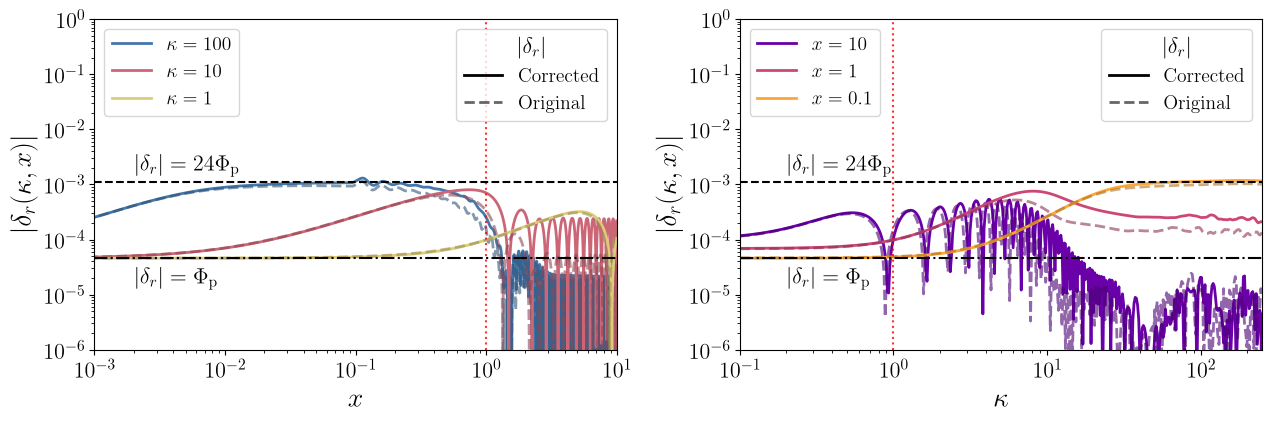

In [10]:
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgb

mat_delta_r = np.abs(np.array(delta_r_k))
mat_delta_r2 = np.abs(np.array(delta_r_k2))
x = R/R_RH

target_kappas = [100.0, 10.0, 1.0]
idx_kappas = [int(np.argmin(np.abs(kappas - k_val))) for k_val in target_kappas]

target_xs = [10, 1.0, 0.1]
idx_xs = [int(np.argmin(np.abs(x - x_val))) for x_val in target_xs]

mode_colors = ["#4477AA", "#CC6677", "#DDCC77", "#117733"]
slice_colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(target_xs)))

output_dir = "Plots/NSC_pert"
__import__("pathlib").Path(output_dir).mkdir(parents=True, exist_ok=True)

def darken(color, f=0.7):
    r, g, b = to_rgb(color)
    return (f*r, f*g, f*b)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax_left, ax_right = axes

old_alpha = 0.6

for k_val, idx_k, color in zip(target_kappas, idx_kappas, mode_colors):
    ax_left.loglog(x, mat_delta_r[idx_k, :], color=color, lw=2, ls="-")
    ax_left.loglog(x, mat_delta_r2[idx_k, :], color=darken(color), lw=2, ls="--", alpha=old_alpha)

for x_val, idx_x, color in zip(target_xs, idx_xs, slice_colors):
    ax_right.loglog(kappas, mat_delta_r[:, idx_x], color=color, lw=2, ls="-")
    ax_right.loglog(kappas, mat_delta_r2[:, idx_x], color=darken(color), lw=2, ls="--", alpha=old_alpha)

for ax in axes:
    ax.axvline(1.0, color="red", linestyle=":", alpha=0.8)

for y_val, color, linestyle, text, va in [(24*Phi_p, "black", "--", r"$|\delta_r|=24\Phi_{\mathrm p}$", "bottom"), (Phi_p, "black", "-.", r"$|\delta_r|=\Phi_{\mathrm p}$", "top")]:
    ax_left.axhline(y_val, color=color, linestyle=linestyle)
    ax_right.axhline(y_val, color=color, linestyle=linestyle)
    ax_left.text(2e-3, y_val*(1.25 if va == "bottom" else 0.7), text, color=color, va=va)
    ax_right.text(2e-1, y_val*(1.25 if va == "bottom" else 0.7), text, color=color, va=va)

ax_left.set_xlabel(labx)
ax_left.set_ylabel(labdr)
ax_left.set_xlim(1e-3, maxi)
ax_left.set_ylim(1e-6, 1e0)

ax_right.set_xlabel(labka)
ax_right.set_ylabel(labdr)
ax_right.set_xlim(kappas[0], kappas[-1])
ax_right.set_ylim(1e-6, 1e0)

kappa_handles = [Line2D([0], [0], color=color, lw=2, label=fr"$\kappa={k_val:g}$") for k_val, color in zip(target_kappas, mode_colors)]
x_handles = [Line2D([0], [0], color=color, lw=2, label=fr"$x={x_val:g}$") for x_val, color in zip(target_xs, slice_colors)]
style_handles = [
    Line2D([0], [0], color="black", lw=2, ls="-", label=r"Corrected"),
    Line2D([0], [0], color="black", lw=2, ls="--", alpha=old_alpha, label=r"Original")
]
leg1 = ax_left.legend(handles=kappa_handles, loc="upper left")
ax_left.add_artist(leg1)
ax_left.legend(handles=style_handles, loc="upper right", title=r"$|\delta_r|$")

leg2 = ax_right.legend(handles=x_handles, loc="upper left")
ax_right.add_artist(leg2)
ax_right.legend(handles=style_handles, loc="upper right", title=r"$|\delta_r|$")

fig.tight_layout()
pdf_name = f"{output_dir}/NSC_delta_r_corrected_vs_old_2panel.pdf"
fig.savefig(pdf_name, bbox_inches="tight", dpi=300)
print(f"Saved: {pdf_name}")
plt.show()
plt.close(fig)